# Analyze Token per Class

Determine which codebook token belongs to which class (TUM, STR, LYM, NEC) based on token usage statistics.

In [54]:
import os
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

In [55]:
# Configuration
ANALYSIS_DIR = "../codebook_analysis_bcss_gumbel8"
CLASSES = ["TUM", "STR", "LYM", "NEC"]
CLASS_COLORS = ['red', 'green', 'blue', 'orange']
N_EMBED = 8192  # Number of codebook tokens

## 1. Load Token Histograms from Each Class

In [56]:
# Load token histogram for each class
token_class_count = np.zeros((N_EMBED, len(CLASSES)), dtype=np.int64)

for i, cls_name in enumerate(CLASSES):
    hist_path = os.path.join(ANALYSIS_DIR, cls_name, "token_histogram.npy")
    
    if os.path.exists(hist_path):
        hist = np.load(hist_path)
        token_class_count[:, i] = hist
        print(f"{cls_name}: loaded {hist.sum():,} total tokens from histogram")
    else:
        print(f"Warning: {hist_path} not found")

print(f"\nTotal tokens across all classes: {token_class_count.sum():,}")

TUM: loaded 102,400 total tokens from histogram
STR: loaded 102,400 total tokens from histogram
LYM: loaded 102,400 total tokens from histogram
NEC: loaded 102,400 total tokens from histogram

Total tokens across all classes: 409,600


## 2. Compute Token-to-Class Mapping

In [57]:
# Determine dominant class for each token
token_to_class = np.argmax(token_class_count, axis=1)  # [N_EMBED]

# Compute confidence (ratio of dominant class usage to total usage)
total_usage = token_class_count.sum(axis=1)
max_usage = token_class_count.max(axis=1)
token_confidence = np.divide(max_usage, total_usage, 
                              out=np.zeros_like(max_usage, dtype=float), 
                              where=total_usage > 0)

# Statistics
used_tokens = total_usage > 0
print(f"Used tokens: {used_tokens.sum()}/{N_EMBED} ({used_tokens.sum()/N_EMBED*100:.1f}%)")
print(f"Unused tokens: {(~used_tokens).sum()}/{N_EMBED}")

Used tokens: 2880/8192 (35.2%)
Unused tokens: 5312/8192


In [58]:
# Count tokens per class
print("\nTokens per class (dominant assignment):")
print("="*50)

for i, cls_name in enumerate(CLASSES):
    class_tokens = np.sum((token_to_class == i) & used_tokens)
    high_conf = np.sum((token_to_class == i) & (token_confidence > 0.5) & used_tokens)
    very_high_conf = np.sum((token_to_class == i) & (token_confidence > 0.8) & used_tokens)
    
    print(f"{cls_name}: {class_tokens} tokens")
    print(f"    - >50% confidence: {high_conf}")
    print(f"    - >80% confidence: {very_high_conf}")


Tokens per class (dominant assignment):
TUM: 861 tokens
    - >50% confidence: 55
    - >80% confidence: 5
STR: 535 tokens
    - >50% confidence: 16
    - >80% confidence: 2
LYM: 800 tokens
    - >50% confidence: 70
    - >80% confidence: 4
NEC: 684 tokens
    - >50% confidence: 15
    - >80% confidence: 3


## 3. Visualizations

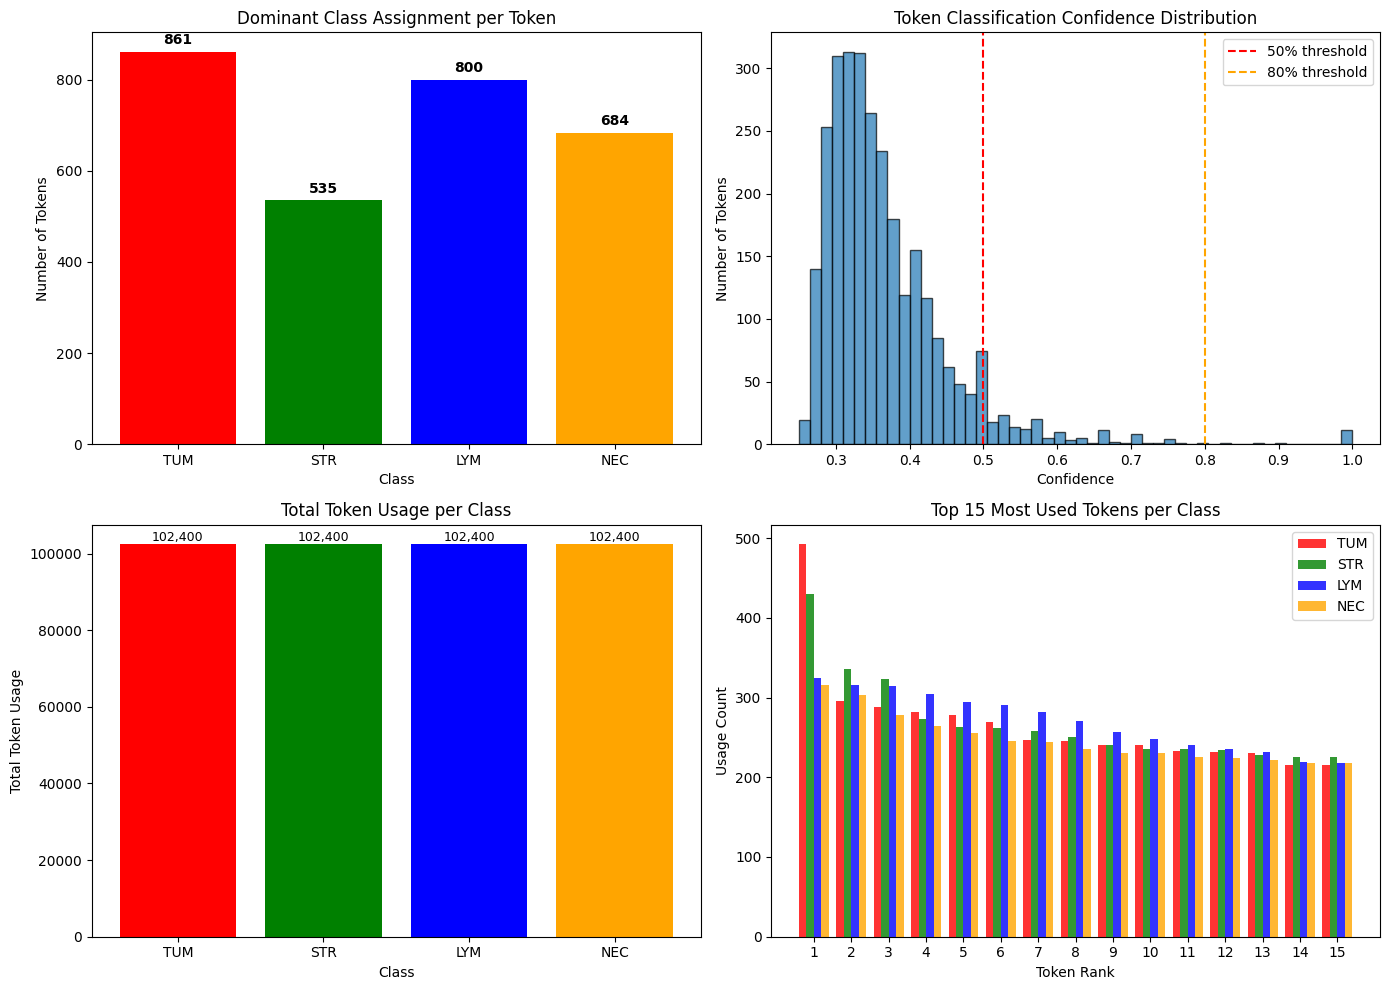

In [59]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Token count per class
ax = axes[0, 0]
class_counts = [np.sum((token_to_class == i) & used_tokens) for i in range(len(CLASSES))]
bars = ax.bar(CLASSES, class_counts, color=CLASS_COLORS)
ax.set_xlabel('Class')
ax.set_ylabel('Number of Tokens')
ax.set_title('Dominant Class Assignment per Token')
for bar, count in zip(bars, class_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(count), ha='center', va='bottom', fontweight='bold')

# Plot 2: Confidence distribution
ax = axes[0, 1]
ax.hist(token_confidence[used_tokens], bins=50, edgecolor='black', alpha=0.7)
ax.axvline(x=0.5, color='r', linestyle='--', label='50% threshold')
ax.axvline(x=0.8, color='orange', linestyle='--', label='80% threshold')
ax.set_xlabel('Confidence')
ax.set_ylabel('Number of Tokens')
ax.set_title('Token Classification Confidence Distribution')
ax.legend()

# Plot 3: Total usage per class
ax = axes[1, 0]
total_per_class = token_class_count.sum(axis=0)
bars = ax.bar(CLASSES, total_per_class, color=CLASS_COLORS)
ax.set_xlabel('Class')
ax.set_ylabel('Total Token Usage')
ax.set_title('Total Token Usage per Class')
for bar, count in zip(bars, total_per_class):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{count:,}', ha='center', va='bottom', fontsize=9)

# Plot 4: Top tokens per class
ax = axes[1, 1]
top_k = 15
x_positions = np.arange(top_k)
width = 0.2

for class_id, class_name in enumerate(CLASSES):
    class_usage = token_class_count[:, class_id]
    top_tokens = np.argsort(class_usage)[-top_k:][::-1]
    top_counts = class_usage[top_tokens]
    ax.bar(x_positions + class_id * width, top_counts, width,
           label=class_name, color=CLASS_COLORS[class_id], alpha=0.8)

ax.set_xlabel('Token Rank')
ax.set_ylabel('Usage Count')
ax.set_title(f'Top {top_k} Most Used Tokens per Class')
ax.legend()
ax.set_xticks(x_positions + 1.5 * width)
ax.set_xticklabels([str(i+1) for i in range(top_k)])

plt.tight_layout()
plt.savefig(os.path.join(ANALYSIS_DIR, "token_class_analysis.png"), dpi=150, bbox_inches='tight')
plt.show()

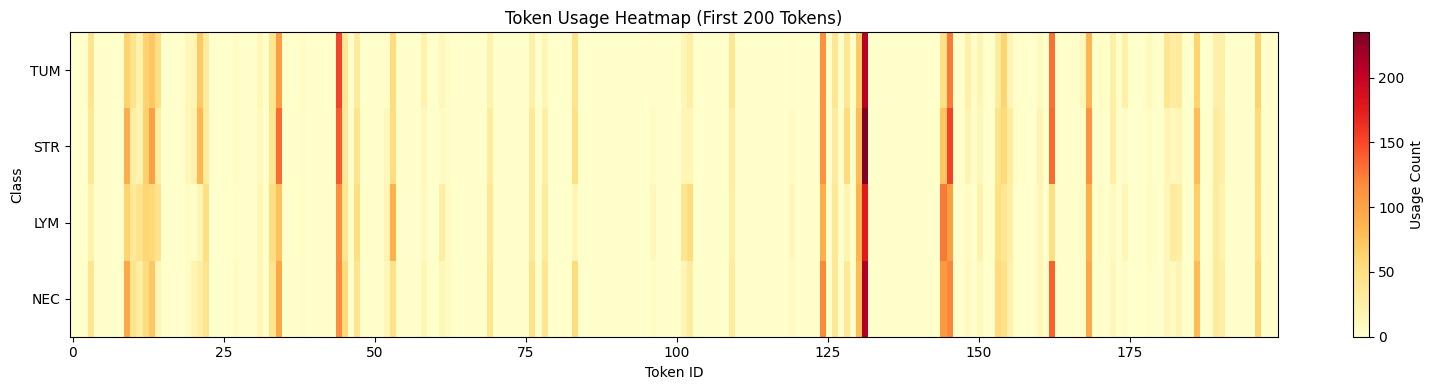

In [60]:
# Heatmap of token usage
fig, ax = plt.subplots(figsize=(16, 4))

# Show first 200 tokens
sample_tokens = 200
sample_data = token_class_count[:sample_tokens, :]

im = ax.imshow(sample_data.T, aspect='auto', cmap='YlOrRd')
ax.set_xlabel('Token ID')
ax.set_ylabel('Class')
ax.set_yticks(range(len(CLASSES)))
ax.set_yticklabels(CLASSES)
ax.set_title(f'Token Usage Heatmap (First {sample_tokens} Tokens)')
plt.colorbar(im, ax=ax, label='Usage Count')

plt.tight_layout()
plt.savefig(os.path.join(ANALYSIS_DIR, "token_heatmap.png"), dpi=150, bbox_inches='tight')
plt.show()

## 4. Top Tokens per Class

In [61]:
# Print top 10 tokens for each class
print("TOP 10 TOKENS PER CLASS")
print("="*60)

for class_id, class_name in enumerate(CLASSES):
    print(f"\n{class_name}:")
    class_usage = token_class_count[:, class_id]
    top_tokens = np.argsort(class_usage)[-10:][::-1]
    
    for rank, token_id in enumerate(top_tokens, 1):
        usage = class_usage[token_id]
        total = token_class_count[token_id].sum()
        conf = usage / total if total > 0 else 0
        print(f"  {rank:2d}. Token {token_id:4d}: {usage:6d} uses ({conf*100:5.1f}% of token's total)")

TOP 10 TOKENS PER CLASS

TUM:
   1. Token 3088:    492 uses ( 33.8% of token's total)
   2. Token 5780:    296 uses ( 32.6% of token's total)
   3. Token 4711:    288 uses ( 31.0% of token's total)
   4. Token 3526:    282 uses ( 29.3% of token's total)
   5. Token 2308:    278 uses ( 24.8% of token's total)
   6. Token 1297:    269 uses ( 33.3% of token's total)
   7. Token  808:    247 uses ( 41.9% of token's total)
   8. Token 5810:    246 uses ( 38.5% of token's total)
   9. Token 7733:    240 uses ( 39.3% of token's total)
  10. Token 1836:    240 uses ( 27.1% of token's total)

STR:
   1. Token 3088:    430 uses ( 29.5% of token's total)
   2. Token 1836:    336 uses ( 37.9% of token's total)
   3. Token 2308:    323 uses ( 28.9% of token's total)
   4. Token 3526:    273 uses ( 28.4% of token's total)
   5. Token 7694:    263 uses ( 29.5% of token's total)
   6. Token 3836:    262 uses ( 30.4% of token's total)
   7. Token 7134:    258 uses ( 30.1% of token's total)
   8. Token 

## 5. Class-Specific Tokens (High Confidence)

In [62]:
# Find tokens that are highly specific to each class (>80% confidence)
print("CLASS-SPECIFIC TOKENS (>80% confidence)")
print("="*60)

class_specific_tokens = {}

for class_id, class_name in enumerate(CLASSES):
    class_specific = (token_to_class == class_id) & (token_confidence > 0.8) & used_tokens
    specific_tokens = np.where(class_specific)[0]
    
    class_specific_tokens[class_name] = specific_tokens.tolist()
    
    if len(specific_tokens) > 0:
        # Sort by usage
        usages = token_class_count[specific_tokens, class_id]
        sorted_idx = np.argsort(usages)[::-1]
        top_specific = specific_tokens[sorted_idx[:10]]
        
        print(f"\n{class_name}: {len(specific_tokens)} class-specific tokens")
        for token_id in top_specific:
            usage = token_class_count[token_id, class_id]
            conf = token_confidence[token_id]
            print(f"  Token {token_id:4d}: {usage:5d} uses, {conf*100:5.1f}% confidence")
    else:
        print(f"\n{class_name}: No class-specific tokens found")

CLASS-SPECIFIC TOKENS (>80% confidence)

TUM: 5 class-specific tokens
  Token  729:     9 uses,  90.0% confidence
  Token 1051:     3 uses, 100.0% confidence
  Token 4641:     1 uses, 100.0% confidence
  Token 3415:     1 uses, 100.0% confidence
  Token 2880:     1 uses, 100.0% confidence

STR: 2 class-specific tokens
  Token 7862:     1 uses, 100.0% confidence
  Token  989:     1 uses, 100.0% confidence

LYM: 4 class-specific tokens
  Token 3699:     7 uses,  87.5% confidence
  Token 4772:     5 uses,  83.3% confidence
  Token 6753:     1 uses, 100.0% confidence
  Token 4809:     1 uses, 100.0% confidence

NEC: 3 class-specific tokens
  Token 6561:     1 uses, 100.0% confidence
  Token 6214:     1 uses, 100.0% confidence
  Token 5875:     1 uses, 100.0% confidence


## 6. Save Token-to-Class Mapping

In [63]:
# Create and save mapping
mapping = {}

for token_id in range(N_EMBED):
    total = token_class_count[token_id].sum()
    if total > 0:
        mapping[int(token_id)] = {
            "class": CLASSES[token_to_class[token_id]],
            "class_id": int(token_to_class[token_id]),
            "confidence": float(token_confidence[token_id]),
            "total_usage": int(total),
            "per_class": {CLASSES[j]: int(token_class_count[token_id, j]) for j in range(len(CLASSES))}
        }

# Save as JSON
mapping_path = os.path.join(ANALYSIS_DIR, "token_to_class_mapping.json")
with open(mapping_path, 'w') as f:
    json.dump(mapping, f, indent=2)
print(f"Saved token mapping to: {mapping_path}")

# Save numpy arrays
np.save(os.path.join(ANALYSIS_DIR, "token_class_count.npy"), token_class_count)
np.save(os.path.join(ANALYSIS_DIR, "token_to_class.npy"), token_to_class)
np.save(os.path.join(ANALYSIS_DIR, "token_confidence.npy"), token_confidence)
print(f"Saved numpy arrays to: {ANALYSIS_DIR}")

Saved token mapping to: ../codebook_analysis_bcss_gumbel8/token_to_class_mapping.json
Saved numpy arrays to: ../codebook_analysis_bcss_gumbel8


In [64]:
# Save class-specific tokens
specific_path = os.path.join(ANALYSIS_DIR, "class_specific_tokens.json")
with open(specific_path, 'w') as f:
    json.dump(class_specific_tokens, f, indent=2)
print(f"Saved class-specific tokens to: {specific_path}")

Saved class-specific tokens to: ../codebook_analysis_bcss_gumbel8/class_specific_tokens.json


## 7. Summary Statistics

In [65]:
print("\n" + "="*60)
print("SUMMARY")
print("="*60)

print(f"\nTotal codebook size: {N_EMBED}")
print(f"Used tokens: {used_tokens.sum()} ({used_tokens.sum()/N_EMBED*100:.1f}%)")
print(f"Unused tokens: {(~used_tokens).sum()} ({(~used_tokens).sum()/N_EMBED*100:.1f}%)")

print(f"\nTokens by dominant class:")
for i, cls_name in enumerate(CLASSES):
    count = np.sum((token_to_class == i) & used_tokens)
    print(f"  {cls_name}: {count} tokens")

print(f"\nHigh-confidence tokens (>80%):")
for i, cls_name in enumerate(CLASSES):
    count = len(class_specific_tokens[cls_name])
    print(f"  {cls_name}: {count} tokens")

print(f"\nMean confidence: {token_confidence[used_tokens].mean():.3f}")
print(f"Median confidence: {np.median(token_confidence[used_tokens]):.3f}")


SUMMARY

Total codebook size: 8192
Used tokens: 2880 (35.2%)
Unused tokens: 5312 (64.8%)

Tokens by dominant class:
  TUM: 861 tokens
  STR: 535 tokens
  LYM: 800 tokens
  NEC: 684 tokens

High-confidence tokens (>80%):
  TUM: 5 tokens
  STR: 2 tokens
  LYM: 4 tokens
  NEC: 3 tokens

Mean confidence: 0.367
Median confidence: 0.345


## 8. Class-Specific Token Frequency Table

Count frequency of each class-specific token across all images in each class folder.

In [66]:
# Count frequency of class-specific tokens across all images
from glob import glob

token_frequency_table = []

for cls_name in CLASSES:
    cls_dir = os.path.join(ANALYSIS_DIR, cls_name)
    npy_files = sorted(glob(os.path.join(cls_dir, "*_tokens.npy")))
    
    if not npy_files:
        print(f"Warning: No token maps found in {cls_dir}")
        continue
    
    print(f"\n{cls_name}: Processing {len(npy_files)} images...")
    
    # Get class-specific tokens for this class
    specific_tokens = class_specific_tokens.get(cls_name, [])
    
    if not specific_tokens:
        print(f"  No class-specific tokens for {cls_name}")
        continue
    
    # Count frequency of each specific token
    token_freq = {token_id: 0 for token_id in specific_tokens}
    
    for npy_file in npy_files:
        token_map = np.load(npy_file).flatten()
        for token_id in specific_tokens:
            token_freq[token_id] += np.sum(token_map == token_id)
    
    # Add to table
    for token_id in specific_tokens:
        freq = token_freq[token_id]
        conf = token_confidence[token_id]
        token_frequency_table.append({
            "class": cls_name,
            "token_id": token_id,
            "frequency": freq,
            "confidence": round(conf, 4),
            "avg_per_image": round(freq / len(npy_files), 2) if npy_files else 0
        })
    
    print(f"  Found {len(specific_tokens)} class-specific tokens")

print(f"\nTotal entries in table: {len(token_frequency_table)}")


TUM: Processing 100 images...
  Found 5 class-specific tokens

STR: Processing 100 images...
  Found 2 class-specific tokens

LYM: Processing 100 images...
  Found 4 class-specific tokens

NEC: Processing 100 images...
  Found 3 class-specific tokens

Total entries in table: 14


In [67]:
# Save as CSV table
import csv

csv_path = os.path.join(ANALYSIS_DIR, "class_specific_token_frequency.csv")

with open(csv_path, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=["class", "token_id", "frequency", "confidence", "avg_per_image"])
    writer.writeheader()
    
    # Sort by class then by frequency descending
    sorted_table = sorted(token_frequency_table, key=lambda x: (x["class"], -x["frequency"]))
    writer.writerows(sorted_table)

print(f"Saved frequency table to: {csv_path}")

# Display top entries per class
print("\n" + "="*70)
print("TOP 5 CLASS-SPECIFIC TOKENS BY FREQUENCY")
print("="*70)

for cls_name in CLASSES:
    cls_entries = [e for e in token_frequency_table if e["class"] == cls_name]
    cls_entries = sorted(cls_entries, key=lambda x: -x["frequency"])[:5]
    
    if cls_entries:
        print(f"\n{cls_name}:")
        print(f"  {'Token ID':<10} {'Frequency':<12} {'Confidence':<12} {'Avg/Image':<10}")
        print(f"  {'-'*44}")
        for e in cls_entries:
            print(f"  {e['token_id']:<10} {e['frequency']:<12} {e['confidence']:<12} {e['avg_per_image']:<10}")

Saved frequency table to: ../codebook_analysis_bcss_gumbel8/class_specific_token_frequency.csv

TOP 5 CLASS-SPECIFIC TOKENS BY FREQUENCY

TUM:
  Token ID   Frequency    Confidence   Avg/Image 
  --------------------------------------------
  729        9            0.9          0.09      
  1051       3            1.0          0.03      
  2880       1            1.0          0.01      
  3415       1            1.0          0.01      
  4641       1            1.0          0.01      

STR:
  Token ID   Frequency    Confidence   Avg/Image 
  --------------------------------------------
  989        1            1.0          0.01      
  7862       1            1.0          0.01      

LYM:
  Token ID   Frequency    Confidence   Avg/Image 
  --------------------------------------------
  3699       7            0.875        0.07      
  4772       5            0.8333       0.05      
  4809       1            1.0          0.01      
  6753       1            1.0          0.01      

NEC

## 9. Shared Tokens Across Multiple Classes

Identify tokens used in 2, 3, or 4 classes.

In [68]:
# Count how many classes use each token
classes_per_token = (token_class_count > 0).sum(axis=1)  # [N_EMBED]

# Find tokens by number of classes
tokens_1_class = np.where(classes_per_token == 1)[0]
tokens_2_classes = np.where(classes_per_token == 2)[0]
tokens_3_classes = np.where(classes_per_token == 3)[0]
tokens_4_classes = np.where(classes_per_token == 4)[0]

print("SHARED TOKENS ANALYSIS")
print("="*60)
print(f"Tokens used in 1 class only:  {len(tokens_1_class)}")
print(f"Tokens used in 2 classes:     {len(tokens_2_classes)}")
print(f"Tokens used in 3 classes:     {len(tokens_3_classes)}")
print(f"Tokens used in 4 classes:     {len(tokens_4_classes)}")
print(f"Unused tokens:                {(classes_per_token == 0).sum()}")

SHARED TOKENS ANALYSIS
Tokens used in 1 class only:  11
Tokens used in 2 classes:     32
Tokens used in 3 classes:     91
Tokens used in 4 classes:     2746
Unused tokens:                5312


In [69]:
# Create detailed table for shared tokens
shared_tokens_table = []

def get_classes_for_token(token_id):
    """Get list of classes that use this token"""
    return [CLASSES[i] for i in range(len(CLASSES)) if token_class_count[token_id, i] > 0]

# Process tokens used in 2+ classes
for token_id in np.where(classes_per_token >= 2)[0]:
    classes_used = get_classes_for_token(token_id)
    total = token_class_count[token_id].sum()
    
    shared_tokens_table.append({
        "token_id": int(token_id),
        "num_classes": len(classes_used),
        "classes": ",".join(classes_used),
        "total_usage": int(total),
        "TUM": int(token_class_count[token_id, 0]),
        "STR": int(token_class_count[token_id, 1]),
        "LYM": int(token_class_count[token_id, 2]),
        "NEC": int(token_class_count[token_id, 3]),
        "dominant_class": CLASSES[token_to_class[token_id]],
        "confidence": round(float(token_confidence[token_id]), 4)
    })

# Save to CSV
csv_path = os.path.join(ANALYSIS_DIR, "shared_tokens.csv")
with open(csv_path, 'w', newline='') as f:
    fieldnames = ["token_id", "num_classes", "classes", "total_usage", "TUM", "STR", "LYM", "NEC", "dominant_class", "confidence"]
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    
    # Sort by num_classes descending, then total_usage descending
    sorted_table = sorted(shared_tokens_table, key=lambda x: (-x["num_classes"], -x["total_usage"]))
    writer.writerows(sorted_table)

print(f"Saved shared tokens to: {csv_path}")
print(f"Total shared tokens (2+ classes): {len(shared_tokens_table)}")

Saved shared tokens to: ../codebook_analysis_bcss_gumbel8/shared_tokens.csv
Total shared tokens (2+ classes): 2869


In [70]:
# Display top shared tokens for each category
print("\n" + "="*70)
print("TOP 10 TOKENS USED IN 4 CLASSES (most shared)")
print("="*70)

tokens_4 = [t for t in shared_tokens_table if t["num_classes"] == 4]
tokens_4 = sorted(tokens_4, key=lambda x: -x["total_usage"])[:10]

if tokens_4:
    print(f"{'Token':<8} {'Total':<8} {'TUM':<8} {'STR':<8} {'LYM':<8} {'NEC':<8} {'Dominant':<10}")
    print("-"*70)
    for t in tokens_4:
        print(f"{t['token_id']:<8} {t['total_usage']:<8} {t['TUM']:<8} {t['STR']:<8} {t['LYM']:<8} {t['NEC']:<8} {t['dominant_class']:<10}")
else:
    print("No tokens used in all 4 classes")

print("\n" + "="*70)
print("TOP 10 TOKENS USED IN 3 CLASSES")
print("="*70)

tokens_3 = [t for t in shared_tokens_table if t["num_classes"] == 3]
tokens_3 = sorted(tokens_3, key=lambda x: -x["total_usage"])[:10]

if tokens_3:
    print(f"{'Token':<8} {'Classes':<20} {'Total':<8} {'Dominant':<10} {'Conf':<8}")
    print("-"*70)
    for t in tokens_3:
        print(f"{t['token_id']:<8} {t['classes']:<20} {t['total_usage']:<8} {t['dominant_class']:<10} {t['confidence']:<8}")
else:
    print("No tokens used in exactly 3 classes")

print("\n" + "="*70)
print("TOP 10 TOKENS USED IN 2 CLASSES")
print("="*70)

tokens_2 = [t for t in shared_tokens_table if t["num_classes"] == 2]
tokens_2 = sorted(tokens_2, key=lambda x: -x["total_usage"])[:10]

if tokens_2:
    print(f"{'Token':<8} {'Classes':<15} {'Total':<8} {'Dominant':<10} {'Conf':<8}")
    print("-"*70)
    for t in tokens_2:
        print(f"{t['token_id']:<8} {t['classes']:<15} {t['total_usage']:<8} {t['dominant_class']:<10} {t['confidence']:<8}")
else:
    print("No tokens used in exactly 2 classes")


TOP 10 TOKENS USED IN 4 CLASSES (most shared)
Token    Total    TUM      STR      LYM      NEC      Dominant  
----------------------------------------------------------------------
3088     1457     492      430      232      303      TUM       
2308     1119     278      323      240      278      STR       
2226     971      154      210      291      316      NEC       
3526     961      282      273      182      224      TUM       
6045     939      196      225      282      236      LYM       
958      937      167      235      305      230      LYM       
4711     930      288      234      200      208      TUM       
5780     909      296      250      159      204      TUM       
7694     892      231      263      176      222      STR       
1836     887      240      336      134      177      STR       

TOP 10 TOKENS USED IN 3 CLASSES
Token    Classes              Total    Dominant   Conf    
----------------------------------------------------------------------
1310

## 10. All Tokens Used by Each Class

List all tokens that appear in each class with their usage count.

In [ ]:
# Generate tokens used by each class
tokens_per_class = {}

for class_id, cls_name in enumerate(CLASSES):
    class_usage = token_class_count[:, class_id]
    used_by_class = np.where(class_usage > 0)[0]
    sorted_idx = np.argsort(class_usage[used_by_class])[::-1]
    sorted_tokens = used_by_class[sorted_idx]
    
    token_list = []
    for token_id in sorted_tokens:
        count = int(class_usage[token_id])
        token_list.append({
            "token_id": int(token_id),
            "count": count,
            "is_dominant": CLASSES[token_to_class[token_id]] == cls_name
        })
    
    tokens_per_class[cls_name] = token_list
    print(f"{cls_name}: {len(token_list)} tokens used")

# Save to JSON
tokens_per_class_path = os.path.join(ANALYSIS_DIR, "tokens_per_class.json")
with open(tokens_per_class_path, 'w') as f:
    json.dump(tokens_per_class, f, indent=2)
print(f"\nSaved to: {tokens_per_class_path}")

# Save as CSV for each class
for cls_name in CLASSES:
    csv_path = os.path.join(ANALYSIS_DIR, f"tokens_used_by_{cls_name}.csv")
    with open(csv_path, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=["token_id", "count", "is_dominant"])
        writer.writeheader()
        writer.writerows(tokens_per_class[cls_name])
    print(f"Saved: {csv_path}")

## 11. Classes Used by Each Token

For every token, show which classes use it and their usage counts.

In [ ]:
# Generate classes used by each token with normalized weights
classes_per_token_table = []

for token_id in range(N_EMBED):
    total = token_class_count[token_id].sum()
    if total == 0:
        continue
    
    classes_used = [CLASSES[i] for i in range(len(CLASSES)) if token_class_count[token_id, i] > 0]
    
    # Compute normalized weights (proportions)
    tum_weight = token_class_count[token_id, 0] / total
    str_weight = token_class_count[token_id, 1] / total
    lym_weight = token_class_count[token_id, 2] / total
    nec_weight = token_class_count[token_id, 3] / total
    
    classes_per_token_table.append({
        "token_id": int(token_id),
        "num_classes": len(classes_used),
        "classes": ",".join(classes_used),
        "total_usage": int(total),
        "TUM": int(token_class_count[token_id, 0]),
        "STR": int(token_class_count[token_id, 1]),
        "LYM": int(token_class_count[token_id, 2]),
        "NEC": int(token_class_count[token_id, 3]),
        "TUM_weight": round(float(tum_weight), 4),
        "STR_weight": round(float(str_weight), 4),
        "LYM_weight": round(float(lym_weight), 4),
        "NEC_weight": round(float(nec_weight), 4),
        "dominant_class": CLASSES[token_to_class[token_id]],
        "confidence": round(float(token_confidence[token_id]), 4)
    })

print(f"Total used tokens: {len(classes_per_token_table)}")

# Save to CSV
csv_path = os.path.join(ANALYSIS_DIR, "classes_per_token.csv")
with open(csv_path, 'w', newline='') as f:
    fieldnames = ["token_id", "num_classes", "classes", "total_usage", 
                  "TUM", "STR", "LYM", "NEC",
                  "TUM_weight", "STR_weight", "LYM_weight", "NEC_weight",
                  "dominant_class", "confidence"]
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    sorted_table = sorted(classes_per_token_table, key=lambda x: x["token_id"])
    writer.writerows(sorted_table)

print(f"Saved to: {csv_path}")

# Display sample
print("\nSAMPLE: First 10 tokens (with normalized weights)")
print("="*100)
print(f"{'Token':<8} {'#Cls':<6} {'Total':<8} {'TUM':<6} {'STR':<6} {'LYM':<6} {'NEC':<6} {'TUM_w':<8} {'STR_w':<8} {'LYM_w':<8} {'NEC_w':<8}")
print("-"*100)
for entry in classes_per_token_table[:10]:
    print(f"{entry['token_id']:<8} {entry['num_classes']:<6} {entry['total_usage']:<8} "
          f"{entry['TUM']:<6} {entry['STR']:<6} {entry['LYM']:<6} {entry['NEC']:<6} "
          f"{entry['TUM_weight']:<8} {entry['STR_weight']:<8} {entry['LYM_weight']:<8} {entry['NEC_weight']:<8}")

## 12. Visualize Token Patches

Show sample image patches for each token to understand what visual patterns they represent.

In [ ]:
from PIL import Image

# Configuration for visualization
IMG_ROOT = "../data/BCSS-WSSS/training_single_class"  # Adjust path as needed
PATCH_SIZE = 8  # f8 downsampling = 8x8 pixels per token
IMAGE_SIZE = 256

def get_patches_for_token(token_id, cls_name, max_patches=16):
    """Extract image patches where a specific token appears"""
    cls_dir = os.path.join(ANALYSIS_DIR, cls_name)
    img_dir = os.path.join(IMG_ROOT, cls_name)
    
    patches = []
    npy_files = sorted(glob(os.path.join(cls_dir, "*_tokens.npy")))
    
    for npy_file in npy_files:
        if len(patches) >= max_patches:
            break
            
        token_map = np.load(npy_file)
        locations = np.where(token_map == token_id)
        
        if len(locations[0]) == 0:
            continue
        
        # Get corresponding image
        stem = os.path.basename(npy_file).replace("_tokens.npy", "")
        img_path = os.path.join(img_dir, f"{stem}.png")
        if not os.path.exists(img_path):
            img_path = os.path.join(img_dir, f"{stem}.jpg")
        if not os.path.exists(img_path):
            continue
        
        # Load and resize image
        img = Image.open(img_path).convert("RGB")
        img = img.resize((IMAGE_SIZE, IMAGE_SIZE))
        img_np = np.array(img)
        
        # Extract patches at token locations
        for i in range(min(len(locations[0]), max_patches - len(patches))):
            h_idx, w_idx = locations[0][i], locations[1][i]
            
            # Calculate pixel coordinates
            y1 = h_idx * PATCH_SIZE
            x1 = w_idx * PATCH_SIZE
            y2 = min(y1 + PATCH_SIZE, IMAGE_SIZE)
            x2 = min(x1 + PATCH_SIZE, IMAGE_SIZE)
            
            patch = img_np[y1:y2, x1:x2]
            if patch.shape[0] == PATCH_SIZE and patch.shape[1] == PATCH_SIZE:
                patches.append(patch)
    
    return patches

def visualize_token(token_id, max_patches=16):
    """Visualize patches for a specific token across all classes"""
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    for i, cls_name in enumerate(CLASSES):
        patches = get_patches_for_token(token_id, cls_name, max_patches)
        
        if patches:
            # Create grid of patches
            n_patches = len(patches)
            grid_size = int(np.ceil(np.sqrt(n_patches)))
            grid = np.zeros((grid_size * PATCH_SIZE, grid_size * PATCH_SIZE, 3), dtype=np.uint8)
            
            for j, patch in enumerate(patches):
                row = j // grid_size
                col = j % grid_size
                grid[row*PATCH_SIZE:(row+1)*PATCH_SIZE, col*PATCH_SIZE:(col+1)*PATCH_SIZE] = patch
            
            axes[i].imshow(grid)
            axes[i].set_title(f"{cls_name}\n({len(patches)} patches)")
        else:
            axes[i].text(0.5, 0.5, "No patches", ha='center', va='center')
            axes[i].set_title(f"{cls_name}\n(0 patches)")
        
        axes[i].axis('off')
    
    usage = token_class_count[token_id]
    conf = token_confidence[token_id]
    dom_class = CLASSES[token_to_class[token_id]]
    
    fig.suptitle(f"Token {token_id} | Dominant: {dom_class} ({conf*100:.1f}%) | Usage: TUM={usage[0]}, STR={usage[1]}, LYM={usage[2]}, NEC={usage[3]}", 
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    return fig

In [ ]:
# Visualize top tokens for each class
print("Visualizing top 3 tokens per class...")

vis_dir = os.path.join(ANALYSIS_DIR, "token_visualizations")
os.makedirs(vis_dir, exist_ok=True)

for cls_name in CLASSES:
    print(f"\n{cls_name}:")
    class_id = CLASSES.index(cls_name)
    
    # Get top 3 tokens for this class
    class_usage = token_class_count[:, class_id]
    top_tokens = np.argsort(class_usage)[-3:][::-1]
    
    for token_id in top_tokens:
        fig = visualize_token(token_id)
        save_path = os.path.join(vis_dir, f"token_{token_id}_{cls_name}.png")
        fig.savefig(save_path, dpi=100, bbox_inches='tight')
        plt.close(fig)
        print(f"  Token {token_id}: saved to {save_path}")

print(f"\nSaved visualizations to: {vis_dir}")

In [ ]:
# Visualize a specific token (change token_id to explore)
token_id = 3088  # Example: most used token in TUM

fig = visualize_token(token_id)
plt.show()

# To visualize another token, change token_id above and run this cell again